1. Import library yang dibutuhin 

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from IPython.display import display

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

2. Ambil data

In [39]:
file_path = 'spam.csv'

try:
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        print("UTF-8 decoding failed, trying 'latin1'...")
        df = pd.read_csv(file_path, encoding='latin1')

    print("Dataset loaded successfully!")
    print("\nDataset Information:")
    df.info()
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

UTF-8 decoding failed, trying 'latin1'...
Dataset loaded successfully!

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


3. EDA ( Exploratory Data analysis)

In [40]:
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

print("\nMissing Values:")
display(df.isnull().sum())

print("\nUnique values in 'v1' column (if applicable):")
if 'v1' in df.columns:
    print(df['v1'].value_counts())
else:
    print("'v1' column not found.")

print("\nUnique values in 'v2' column (if applicable):")
if 'v2' in df.columns:
    print(df['v2'].head())
else:
    print("'v2' column not found.")


Descriptive Statistics:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2



Missing Values:


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


Unique values in 'v1' column (if applicable):
v1
ham     4825
spam     747
Name: count, dtype: int64

Unique values in 'v2' column (if applicable):
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: v2, dtype: str


4. Proses

In [41]:
df_cleaned = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
df_cleaned = df_cleaned.rename(columns={'v1': 'label', 'v2': 'message'})

# Tambahkan kolom panjang pesan
df_cleaned['message_length'] = df_cleaned['message'].apply(len)

# [PENTING] Ubah label teks menjadi numerik (0 = ham, 1 = spam)
df_cleaned['label'] = df_cleaned['label'].map({'ham': 0, 'spam': 1})

# Hapus baris yang kosong setelah mapping (untuk keamanan)
df_cleaned = df_cleaned.dropna(subset=['label'])

# Inisialisasi NLTK tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower() # Mengubah teks menjadi huruf kecil semua
    text = re.sub(r'[^a-z\s]', '', text) # Menghapus tanda baca dan angka
    words = text.split() # Tokenisasi sederhana berbasis spasi
    # Lemmatization & Stopword removal
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

# Terapkan pembersihan dan buat kolom baru
df_cleaned['clean_message'] = df_cleaned['message'].apply(clean_text)

print("\nDataset setelah dibersihkan dan diproses:")
display(df_cleaned[['label', 'message', 'clean_message']].head())


Dataset setelah dibersihkan dan diproses:


,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


5.  Vectorisasi..? dari teks ke angka

In [42]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.9)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_cleaned['clean_message'])

print("Bentuk matriks TF-IDF:", tfidf_matrix.shape)
print("Contoh fitur (kata-kata) yang digunakan:", tfidf_vectorizer.get_feature_names_out()[:20])

Bentuk matriks TF-IDF: (5572, 3532)
Contoh fitur (kata-kata) yang digunakan: ['aah' 'aathilove' 'aathiwhere' 'abi' 'ability' 'abiola' 'abj' 'able'
 'abt' 'abta' 'aburo' 'ac' 'acc' 'accept' 'access' 'accident'
 'accidentally' 'accordingly' 'account' 'ache']


6. Train-Test Split (Membagi Data Latih dan Uji)

In [43]:
#Pisahin X dan Y
X = tfidf_matrix
y = df_cleaned['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih (Training):", X_train.shape[0])
print("Jumlah data uji (Testing):", X_test.shape[0])


Jumlah data latih (Training): 4457
Jumlah data uji (Testing): 1115


7. Model 1: Linear SVM (Support Vector Machine)

--- Evaluasi Linear SVM ---
Akurasi: 0.9847533632286996

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



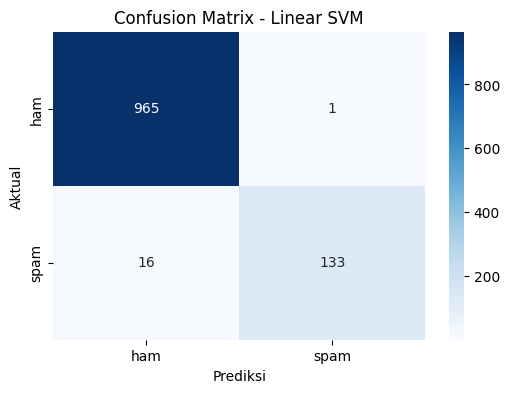

In [44]:
# Inisialisasi dan latih model Linear SVM
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

#prediksi data uji
svm_predictions = svm_model.predict(X_test)

# Evaluasi
print("--- Evaluasi Linear SVM ---")
print("Akurasi:", accuracy_score(y_test, svm_predictions))
print("\nClassification Report:\n", classification_report(y_test, svm_predictions, target_names=['ham', 'spam']))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, svm_predictions), annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


8. Model 2: Logistic Regression

--- Evaluasi Multinomial Naive Bayes ---
Akurasi: 0.9713004484304932

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



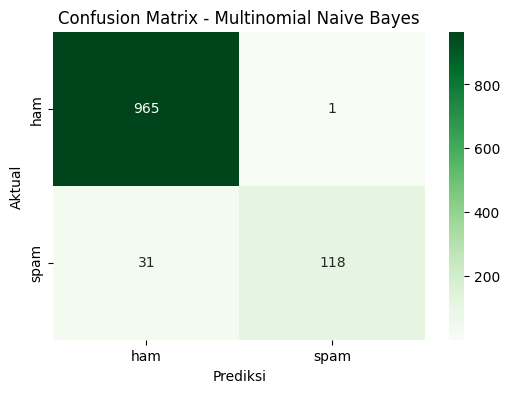

In [45]:
# Inisialisasi dan latih si model Multinomial Naive Bayes

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
nb_predictions = nb_model.predict(X_test)

# Evaluasi
print("--- Evaluasi Multinomial Naive Bayes ---")
print("Akurasi:", accuracy_score(y_test, nb_predictions))
print("\nClassification Report:\n", classification_report(y_test, svm_predictions, target_names=['ham', 'spam']))

# visualin matrik
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, nb_predictions), annot=True, fmt='d', cmap='Greens',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


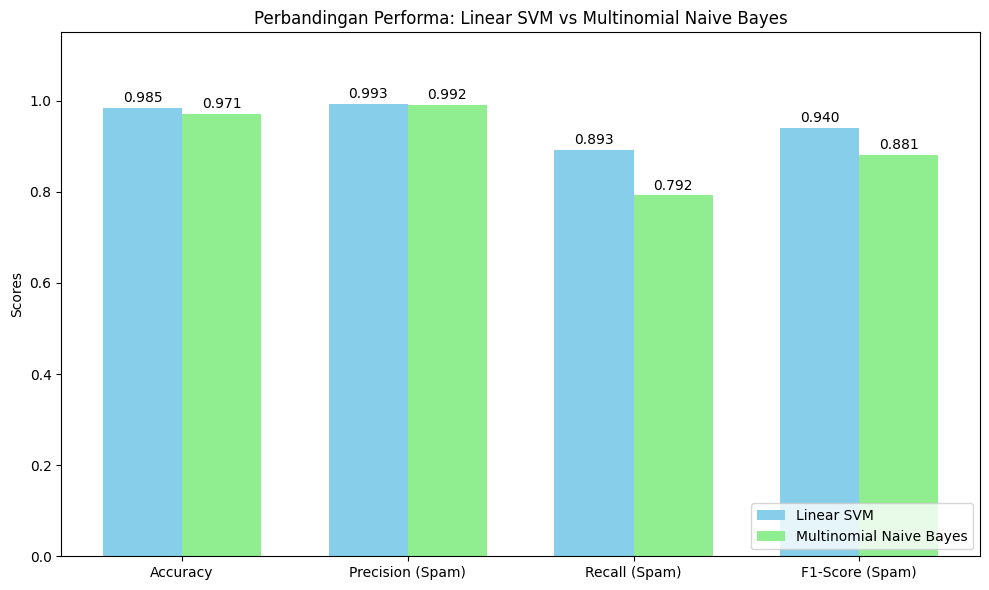

In [46]:
# 10. Perbandingan Performa Model dalam Satu Grafik
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Menghitung metrik SVM
svm_acc = accuracy_score(y_test, svm_predictions)
svm_prec, svm_rec, svm_f1, _ = precision_recall_fscore_support(y_test, svm_predictions, pos_label=1, average='binary')

# Menghitung metrik untuk Multinomial Naive Bayes
nb_acc = accuracy_score(y_test, nb_predictions)
nb_prec, nb_rec, nb_f1, _ = precision_recall_fscore_support(y_test, nb_predictions, pos_label=1, average='binary')

# Data buat plot
metrics = ['Accuracy', 'Precision (Spam)', 'Recall (Spam)', 'F1-Score (Spam)']
svm_scores = [svm_acc, svm_prec, svm_rec, svm_f1]
nb_scores = [nb_acc, nb_prec, nb_rec, nb_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, svm_scores, width, label='Linear SVM', color='skyblue')
rects2 = ax.bar(x + width/2, nb_scores, width, label='Multinomial Naive Bayes', color='lightgreen')

# Menambahkan teks dan label
ax.set_ylabel('Scores')
ax.set_title('Perbandingan Performa: Linear SVM vs Multinomial Naive Bayes')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')

# Menambahin nilai atas bar
ax.bar_label(rects1, fmt='%.3f', padding=2)
ax.bar_label(rects2, fmt='%.3f', padding=2)

fig.tight_layout()
plt.show()


9. Kesimpulan
- Kedua model Supervised Learning (Linear SVM dan Multinomial Naive Bayes) memberikan hasil akurasi yang sangat tinggi (di atas 95%) untuk deteksi pesan Spam.
- Linear SVM bekerja secara geometris, berfokus pada pencarian margin/batas paling tegas (hyperplane) antara vektor kelas Spam dan Ham.
- Multinomial Naive Bayes bekerja secara probabilistik, menghitung peluang kemunculan fitur (kata) terhadap masing-masing kelas secara independen.
- Linear SVM cenderung memberikan akurasi dan metrik F1 Score yang sedikit lebih mending karena kemampuannya menangani fitur kompleks, namun MNB ini unggul dalam kecepatan komputasi dan sering kali menghasilkan angka False Positive yang lebih rendah.

Serta lebih baik Linear SVM berbeda tipis dengan logistik dalam pengolahan datanya
